# 1. Importing necessary libraries and dataset with engineered features

In [200]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from tensorflow.keras import losses
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [201]:
#Importing the Dataframe with the features

df = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/CA01-MachineLearning/Python-Forecasting-Electrical-Demand-on-Spain/part_2_output_features_engineered.csv',
                parse_dates = ['timestamp'])

In [202]:
#Setting the timestamp as the index

df.set_index('timestamp', inplace = True)

In [203]:
# Visualising the first 5 rows of the dataset

df.head()

,total load actual,total load forecast,year,month,doy,dom,dow,woy,hour,is_leap_year,...,month_cos,doy_sin,doy_cos,woy_sin,woy_cos,season,is_weekend,is_end_of_year,is_christmas,is_holiday
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,25385.0,26118.0,2015,1,1,1,3,1,0,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 01:00:00,24382.0,24934.0,2015,1,1,1,3,1,1,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 02:00:00,22734.0,23515.0,2015,1,1,1,3,1,2,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 03:00:00,21286.0,22642.0,2015,1,1,1,3,1,3,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1
2015-01-01 04:00:00,20264.0,21785.0,2015,1,1,1,3,1,4,False,...,0.866025,0.017213,0.999852,0.120537,0.992709,Winter,False,False,False,1


In [204]:
#Verifying information of all the features of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2015-01-01 00:00:00 to 2018-12-31 23:00:00
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   total load actual    35064 non-null  float64
 1   total load forecast  35064 non-null  float64
 2   year                 35064 non-null  int64  
 3   month                35064 non-null  int64  
 4   doy                  35064 non-null  int64  
 5   dom                  35064 non-null  int64  
 6   dow                  35064 non-null  int64  
 7   woy                  35064 non-null  int64  
 8   hour                 35064 non-null  int64  
 9   is_leap_year         35064 non-null  bool   
 10  hour_sin             35064 non-null  float64
 11  hour_cos             35064 non-null  float64
 12  dow_sin              35064 non-null  float64
 13  dow_cos              35064 non-null  float64
 14  month_sin            35064 non-null  float64
 15  m

In [205]:
#Droping the column with TSA Forecast

df.drop(columns = ['total load forecast'], inplace = True)

In [206]:
#Creating dummies of the season in the dataset

dummies = pd.get_dummies(df['season'], prefix='season')

# Join back to original DataFrame (drop the original if you like)
df = pd.concat([df.drop('season', axis=1), dummies], axis=1)

# 2. Training the model

In [207]:
#Splitting the dataset in training, validation and testing

#Defining the train_validation dataframe
df_train_validation = df.loc['2015-01-01 00:00:00':'2017-12-31 23:00:00']

#Defining the testing dataframe
df_test = df.loc['2018-01-01 00:00:00':'2018-04-01 00:00:00']

It will be defined a train/validation of 70/30 in the df_train_validation dataframe

In [208]:
#Veriyfing the number of records from train

print("Number of records in train/validation: ", round(0.7*len(df_train_validation),0), "/",
                                                 round(0.3*len(df_train_validation),0))

Number of records in train/validation:  18413.0 / 7891.0


In [209]:
#Defining train and validation datasets
df_train = df_train_validation.iloc[:-7891]
df_val = df_train_validation.iloc[-7891:]

In [210]:
#Defining X and y for train, validation and test

X_train = df_train.drop(columns = ['total load actual']).astype('float64')
X_val = df_val.drop(columns = ['total load actual']).astype('float64')
X_test = df_test.drop(columns = ['total load actual']).astype('float64')
y_train = df_train['total load actual'].astype('float64')
y_val = df_val['total load actual'].astype('float64')
y_test = df_test['total load actual'].astype('float64')

In [211]:
#Creating teh model

LGB_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=29,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [212]:
#Training the model

LGB_model_fit = LGB_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[93]	valid_0's l1: 1717.42	valid_0's l2: 5.46339e+06


In [213]:
#Getting prediction with the model trained

LGB_preds = LGB_model_fit.predict(X_test)

In [214]:
#Printing the R2 Score for the model

print("R2", r2_score(y_test.values, LGB_preds))

R2 0.7540429000527514


In [215]:
#Printing MAPE for the model

mape = losses.mape(y_test, LGB_preds)
print(mape)

tf.Tensor(6.246091520227746, shape=(), dtype=float64)


The model imediatelly performs better than the models tested before. Furthermore, the model only takes a few seconds to train. 

Sklearn offers a function that allows to evaluate which feature are actually harming the predictions, making easier to remove them and improve the performance of the model. 

Available keys: dict_keys(['_deprecated_key_to_warnings'])
Harmful features (negative importance): ['month', 'woy', 'month_sin', 'month_cos', 'doy_sin', 'woy_sin', 'woy_cos', 'season_Spring', 'season_Winter']


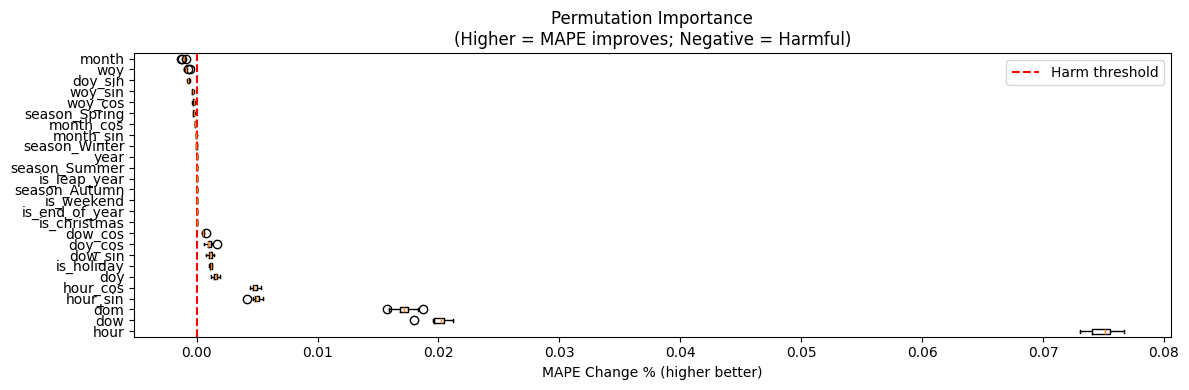


Top 10 Features:
      feature  importance_mean  importance_std
0        hour           0.0749          0.0010
1         dow           0.0200          0.0008
2         dom           0.0172          0.0009
3    hour_sin           0.0050          0.0004
4    hour_cos           0.0048          0.0003
5         doy           0.0016          0.0002
6  is_holiday           0.0012          0.0001
7     dow_sin           0.0011          0.0002
8     doy_cos           0.0010          0.0003
9     dow_cos           0.0006          0.0001

Recommendations:
- Keep: importance > 0.1
- Neutral: |importance| < 0.1
- Drop: importance < 0


In [216]:
# Permutation importance
perm_importance = permutation_importance(
    LGB_model_fit, X_test, y_test, 
    scoring='neg_mean_absolute_percentage_error',
    n_repeats=10, random_state=42, n_jobs=-1
)

#Extracting the importance of the features to the model
importances_mean = perm_importance.importances_mean
importances_std = perm_importance.importances_std
importances = getattr(perm_importance, 'importances', None)  # Safe getattr

print("Available keys:", perm_importance.__dict__.keys())

# Sort descending (higher = better)
sorted_idx = np.argsort(importances_mean)[::-1]

# Harmful features
harmful_mask = importances_mean < 0
harmful_features = X_test.columns[harmful_mask].tolist()
print(f"Harmful features (negative importance): {harmful_features}")

# Plot using importances_mean if raw unavailable
if importances is not None:
    plt.figure(figsize=(12, 4))
    plt.boxplot(importances[sorted_idx].T, 
                labels=X_test.columns[sorted_idx].tolist(), vert=False)
else:
    # Fallback: error bars on mean
    plt.figure(figsize=(12, 4))
    plt.errorbar(importances_mean[sorted_idx], range(len(sorted_idx)), 
                 xerr=importances_std[sorted_idx], fmt='o', capsize=5)
    plt.yticks(range(len(sorted_idx)), X_test.columns[sorted_idx].tolist())
    plt.axvline(0, color='r', linestyle='--')

plt.title('Permutation Importance\n(Higher = MAPE improves; Negative = Harmful)')
plt.xlabel('MAPE Change % (higher better)')
plt.axvline(0, color='r', linestyle='--', label='Harm threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Summary table
summary_df = pd.DataFrame({
    'feature': X_test.columns[sorted_idx],
    'importance_mean': importances_mean[sorted_idx],
    'importance_std': importances_std[sorted_idx]
})
print("\nTop 10 Features:")
print(summary_df.head(10).round(4))

print("\nRecommendations:")
print("- Keep: importance > 0.1")
print("- Neutral: |importance| < 0.1") 
print("- Drop: importance < 0")

Taking into consideration the results presented by the method, the following features will be dropped:

Month, woy, Month Sin & Cos, doy Sin & Cos, woy Sin & Cos, All seasons.

In [217]:
X_train.columns

Index(['year', 'month', 'doy', 'dom', 'dow', 'woy', 'hour', 'is_leap_year',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
       'doy_sin', 'doy_cos', 'woy_sin', 'woy_cos', 'is_weekend',
       'is_end_of_year', 'is_christmas', 'is_holiday', 'season_Autumn',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')

In [218]:
X_train.drop(columns = ['month','woy',
                        'month_sin', 'month_cos',
                        'doy_sin', 'doy_cos',
                        'woy_sin', 'woy_cos', 
                        'season_Autumn','season_Spring', 'season_Summer', 'season_Winter'],
            inplace = True)                       
X_val.drop(columns = ['month','woy',
                        'month_sin', 'month_cos',
                        'doy_sin', 'doy_cos',
                        'woy_sin', 'woy_cos', 
                        'season_Autumn','season_Spring', 'season_Summer', 'season_Winter'],
            inplace = True)                       
X_test.drop(columns = ['month','woy',
                        'month_sin', 'month_cos',
                        'doy_sin', 'doy_cos',
                        'woy_sin', 'woy_cos', 
                        'season_Autumn','season_Spring', 'season_Summer', 'season_Winter'],
            inplace = True)                       

In [219]:
#RE-Training the model

LGB_model_fit = LGB_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(50)]
)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[95]	valid_0's l1: 1711.64	valid_0's l2: 5.3445e+06


In [220]:
#Getting prediction with the model trained

LGB_preds = LGB_model_fit.predict(X_test)

In [221]:
#Printing the R2 Score for the model

print("R2", r2_score(y_test.values, LGB_preds))

R2 0.7769138504199652


In [222]:
#Printing MAPE for the model

mape = losses.mape(y_test, LGB_preds)
print(mape)

tf.Tensor(5.850392384069676, shape=(), dtype=float64)


It is possible to immediately verify a substantial improvement on the model.

The actual against the forecasted will be ploted in a chart.

In [223]:
#Adding the prediction to the test dataset

df_test['LightGBM'] = LGB_preds

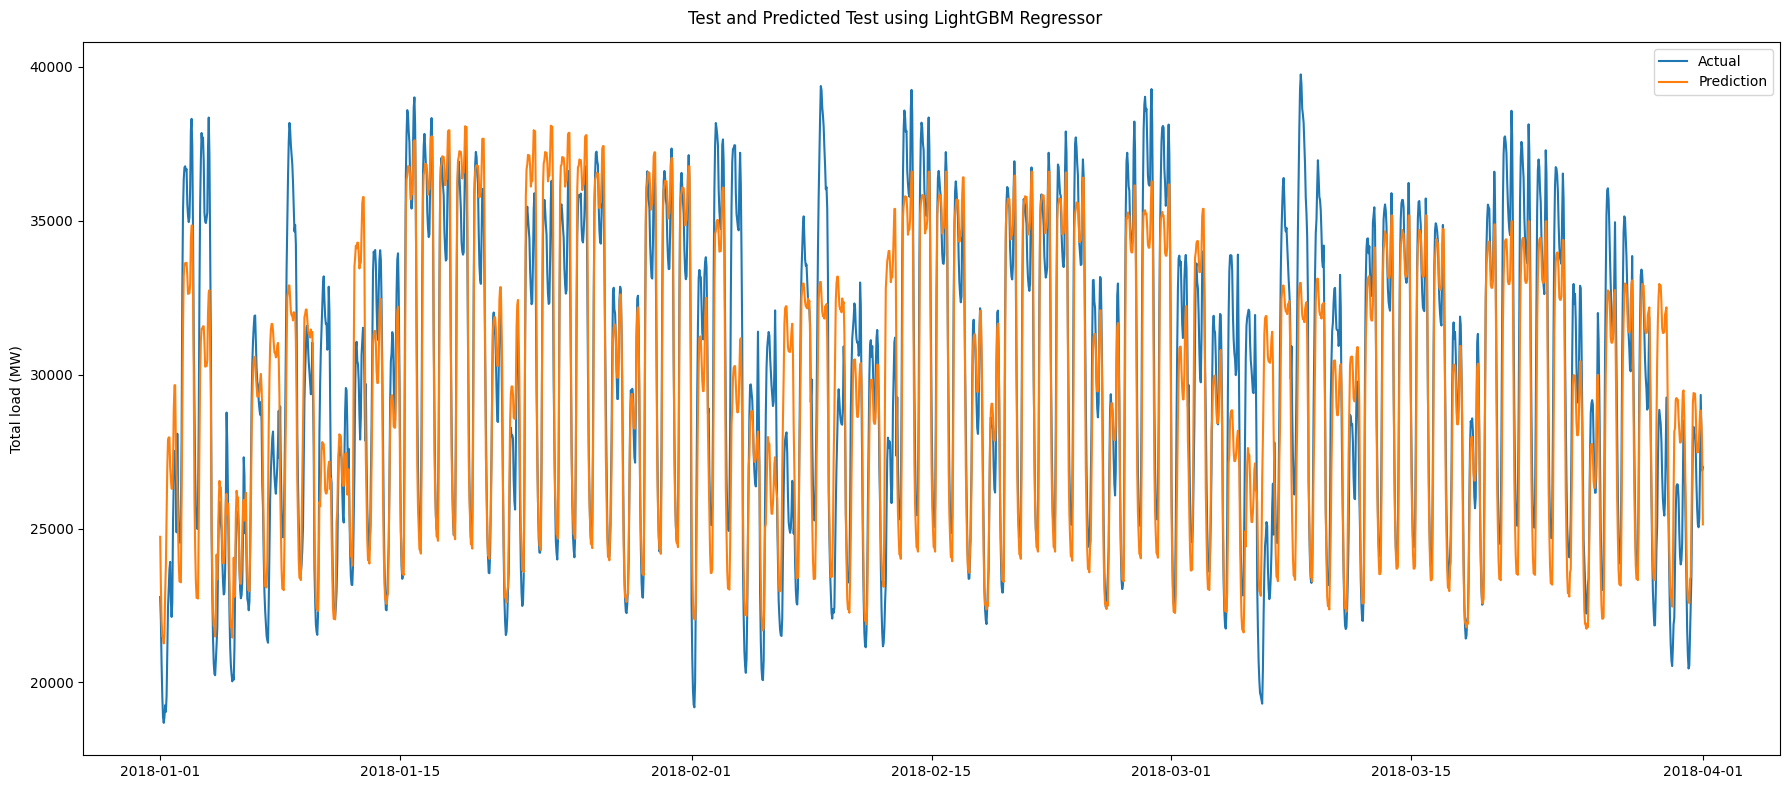

In [224]:
#Plotting predicted data against the original data.

fig, ax = plt.subplots(figsize = [18,8])

ax.plot(df_test.index, df_test['total load actual'], label = 'Actual')
ax.plot(df_test.index, df_test['LightGBM'], label = 'Prediction')
ax.set_ylabel('Total load (MW)')

ax.legend()

# Display the title of the figure
fig.suptitle('Test and Predicted Test using LightGBM Regressor')
fig.tight_layout()
fig.show()

The model captures most of the seasonality on the data and its trends. It stills fails to capture high peaks and low troughs, but that might be related to external conditions that are not possible to be captured only with calendar data. For instance, factors related to weather data. As the objective is reaching the best model considering only calendar data, the result is considered excelent.